## Grid Search Hyperparameter optimization

This case study is all about using grid searches to identify the optimal parameters for a machine learning algorithm. To complere this case study, you'll use the Pima Indian diabetes dataset from Kaggle and KNN. Follow along with the preprocessing steps of this case study.

Load the necessary packages

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# set random seed to try make this exercise and solutions reproducible (NB: this is just for teaching purpose and not something you would do in real life)
random_seed_number = 42
np.random.seed(random_seed_number)

#### Load the diabetes data

In [6]:
diabetes_data = pd.read_csv('data/diabetes.csv')
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**<font color='teal'> Start by reviewing the data info.</font>**

In [9]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**<font color='teal'> Apply the describe function to the data.</font>**

In [12]:
print(diabetes_data.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

**<font color='teal'> Currently, the missing values in the dataset are represented as zeros. Replace the zero values in the following columns ['Glucose','BloodPressure','SkinThickness','Insulin','BMI'] with nan .</font>**

In [16]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes_data[cols] = diabetes_data[cols].replace(0, np.nan)
print(diabetes_data.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  763.000000     733.000000     541.000000  394.000000   
mean      3.845052  121.686763      72.405184      29.153420  155.548223   
std       3.369578   30.535641      12.382158      10.476982  118.775855   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.000000      64.000000      22.000000   76.250000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  141.000000      80.000000      36.000000  190.000000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  757.000000                768.000000  768.000000  768.000000  
mean    32.457464                  0.471876   33.240885    0.348958  
std      6.924988                  0.331329   11.760232    0.476951  
min     18.200000                  

**<font color='teal'> Plot histograms of each column. </font>**

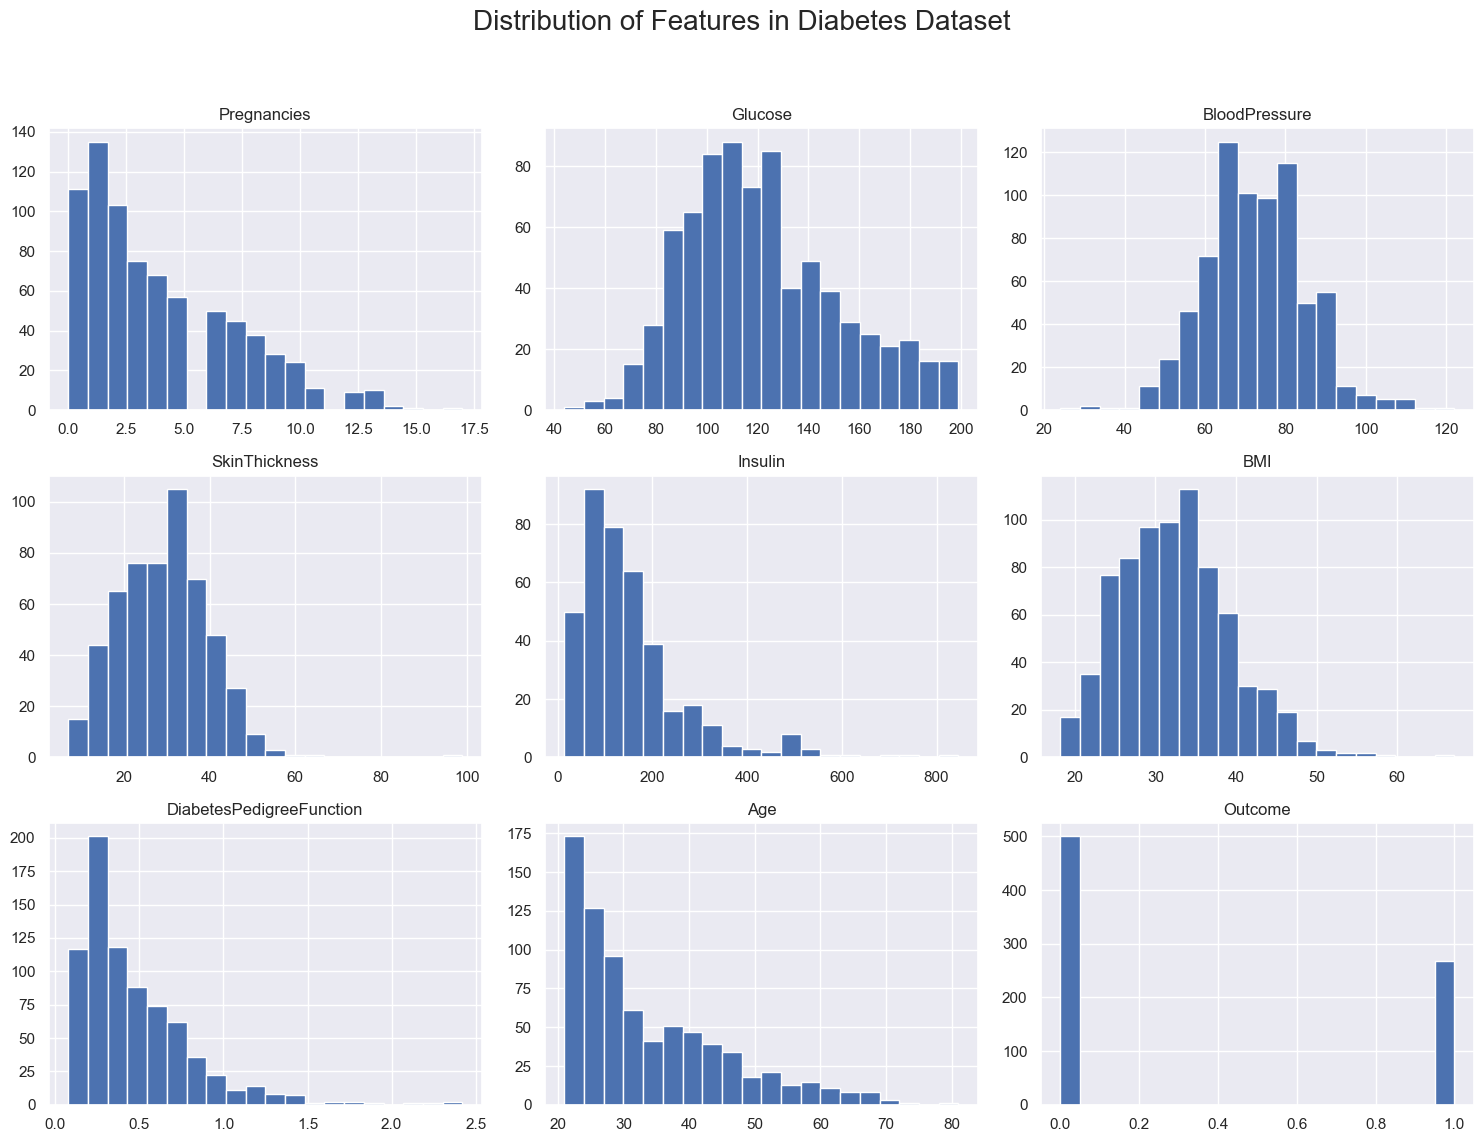

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting histograms for all columns
diabetes_data.hist(figsize=(15, 12), bins=20)

# Formatting the layout
plt.suptitle("Distribution of Features in Diabetes Dataset", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Replace the zeros with mean and median values.

In [53]:
diabetes_data['Glucose'].fillna(diabetes_data['Glucose'].mean(), inplace = True)
diabetes_data['BloodPressure'].fillna(diabetes_data['BloodPressure'].mean(), inplace = True)
diabetes_data['SkinThickness'].fillna(diabetes_data['SkinThickness'].median(), inplace = True)
diabetes_data['Insulin'].fillna(diabetes_data['Insulin'].median(), inplace = True)
diabetes_data['BMI'].fillna(diabetes_data['BMI'].median(), inplace = True)

C:\Users\Irina Kim\AppData\Local\Temp\ipykernel_56508\2273347448.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes_data['Glucose'].fillna(diabetes_data['Glucose'].mean(), inplace = True)
C:\Users\Irina Kim\AppData\Local\Temp\ipykernel_56508\2273347448.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

**<font color='teal'> Plot histograms of each column after replacing nan. </font>**

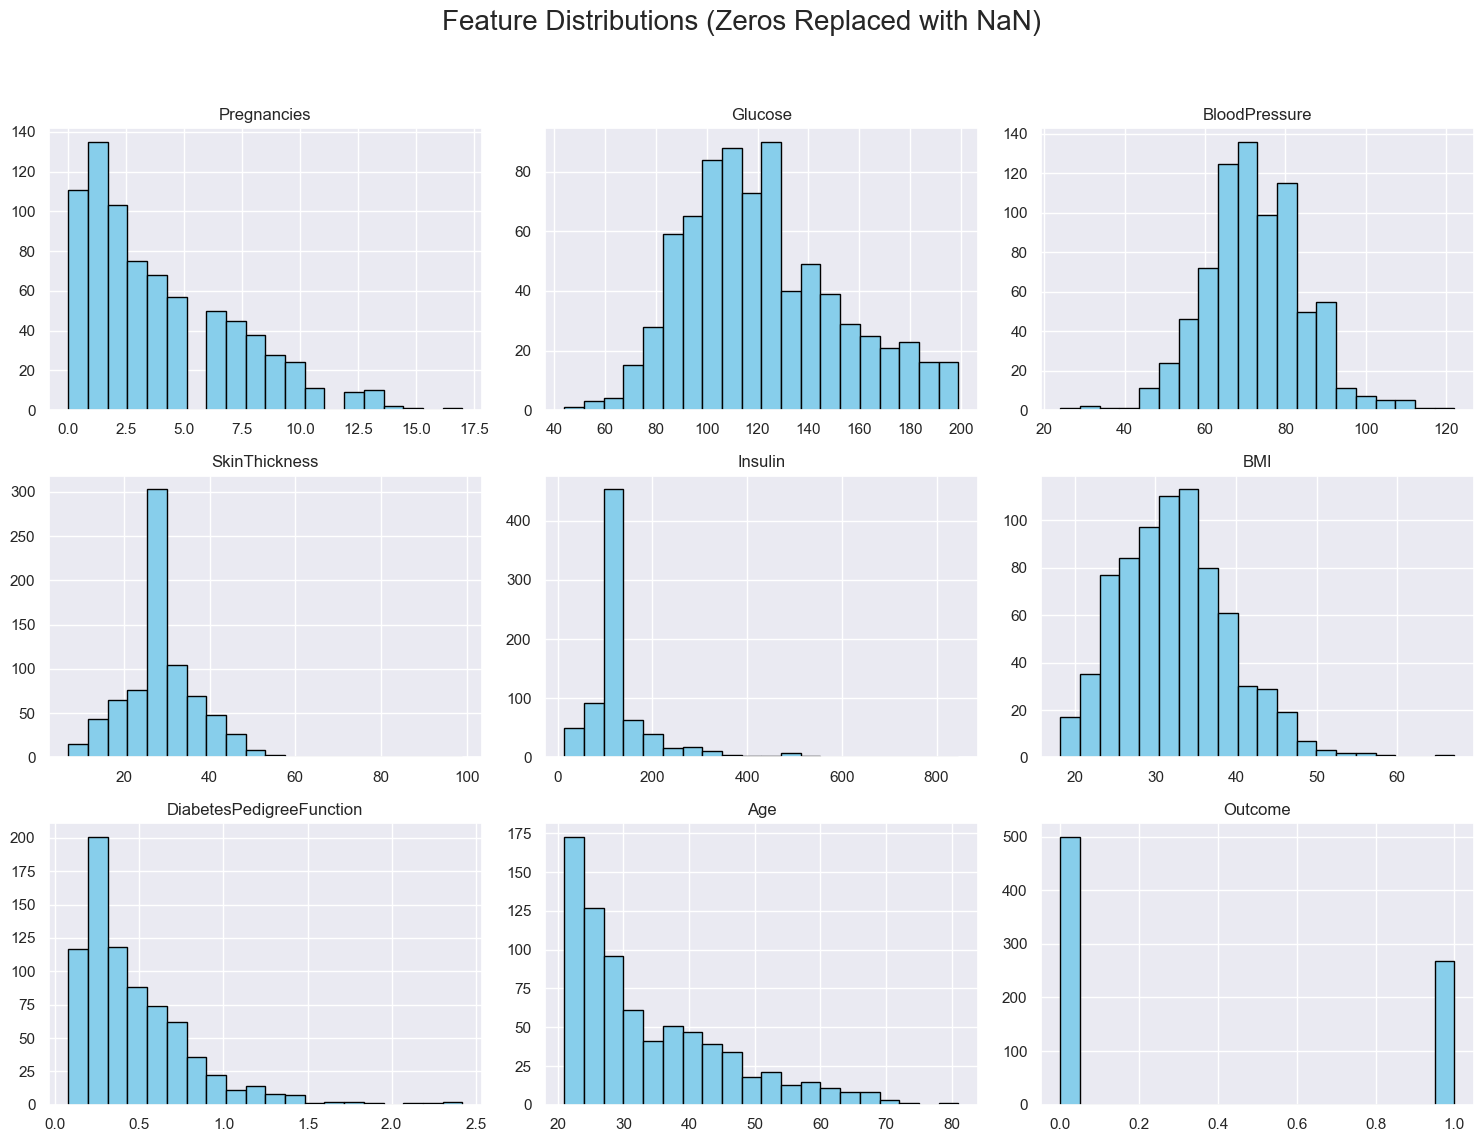

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting histograms for all columns after replacing 0s with NaN
diabetes_data.hist(figsize=(15, 12), bins=20, color='skyblue', edgecolor='black')

plt.suptitle("Feature Distributions (Zeros Replaced with NaN)", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Plot the correlation matrix heatmap

Correlation between various features


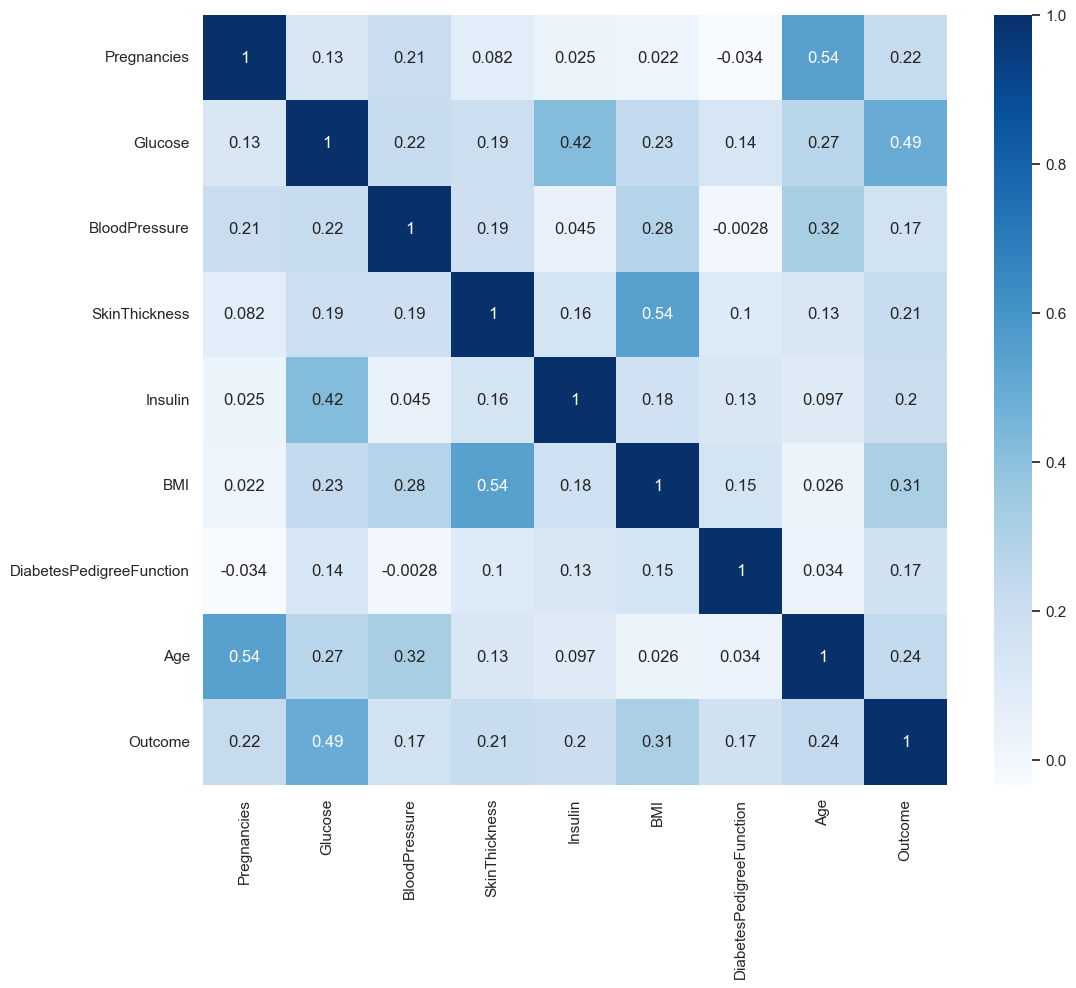

In [57]:
plt.figure(figsize=(12,10))
print('Correlation between various features')
p=sns.heatmap(diabetes_data.corr(), annot=True,cmap ='Blues')

**<font color='teal'> Define the `y` variable as the `Outcome` column.</font>**

In [59]:
y = diabetes_data['Outcome']
print(y.head())
print(y.value_counts())

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64
Outcome
0    500
1    268
Name: count, dtype: int64


**<font color='teal'> Create a 70/30 train and test split. </font>**

In [61]:
from sklearn.model_selection import train_test_split

X = diabetes_data.drop('Outcome', axis=1)

# Create a 70/30 train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Verify the size of the splits
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (537, 8)
Testing set shape: (231, 8)


**<font color='teal'> Using Sklearn, standarize the magnitude of the features by scaling the values. </font>**

Note: Don't forget to fit() your scaler on X_train and then use that fitted scaler to transform() X_test. This is to avoid data leakage while you standardize your data.

In [68]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit on the training data and transform it
# This calculates the mean and std dev for each feature in X_train
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the test data
# We use the same mean and std dev from X_train to ensure consistency
X_test_scaled = scaler.transform(X_test)

# Optional: Convert back to a DataFrame to inspect the result
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print(X_train_scaled_df.head())

   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.836294 -0.896108      -1.004400      -1.269545 -0.956993 -1.203826   
1     0.390728 -0.563997      -0.020266       0.029693  2.136797  0.664498   
2    -1.143050  0.432336      -0.348311       1.565156  1.267755  1.440571   
3     0.083972  0.299491      -0.348311      -0.915207  0.294428  0.118373   
4    -0.836294 -0.630419      -3.464737       1.092706 -0.667312  1.584288   

   DiabetesPedigreeFunction       Age  
0                 -0.614216 -0.948610  
1                 -0.909738 -0.434667  
2                 -0.306991 -0.777296  
3                 -0.906812 -0.434667  
4                 -0.839515 -0.006380  


#### Using a range of neighbor values of 1-10, apply the KNearestNeighbor classifier to classify the the data.

In [70]:
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

test_scores = []
train_scores = []

for i in range(1,10):

    knn = KNeighborsClassifier(i)
    knn.fit(X_train,y_train)
    
    train_scores.append(knn.score(X_train,y_train))
    test_scores.append(knn.score(X_test,y_test))

**<font color='teal'> Print the train and test scores for each iteration.</font>**

In [74]:
for i in range(1, 10):
    knn = KNeighborsClassifier(i)
    knn.fit(X_train_scaled, y_train)
    
    train_score = knn.score(X_train_scaled, y_train)
    test_score = knn.score(X_test_scaled, y_test)
    
    print(f"K = {i} | Train Score: {train_score:.4f} | Test Score: {test_score:.4f}")

K = 1 | Train Score: 1.0000 | Test Score: 0.6667
K = 2 | Train Score: 0.8510 | Test Score: 0.6710
K = 3 | Train Score: 0.8547 | Test Score: 0.6710
K = 4 | Train Score: 0.8417 | Test Score: 0.6926
K = 5 | Train Score: 0.8399 | Test Score: 0.7013
K = 6 | Train Score: 0.8231 | Test Score: 0.6840
K = 7 | Train Score: 0.8343 | Test Score: 0.7316
K = 8 | Train Score: 0.8212 | Test Score: 0.7359
K = 9 | Train Score: 0.8268 | Test Score: 0.7316


**<font color='teal'> Identify the number of neighbors that resulted in the max score in the training dataset. </font>**

In [76]:
from sklearn.model_selection import GridSearchCV

# 1. Define the range of parameters to test
param_grid = {'n_neighbors': np.arange(1, 50)}

# 2. Initialize the KNN model
knn = KNeighborsClassifier()

# 3. Initialize GridSearchCV with 5-fold cross-validation
# We use the scaled training data to avoid data leakage
knn_cv = GridSearchCV(knn, param_grid, cv=5)

# 4. Fit the grid search to the data
knn_cv.fit(X_train_scaled, y_train)

# 5. Print the results
print("Best Score: " + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score: 0.7951021114572516
Best Parameters: {'n_neighbors': 11}


**<font color='teal'> Identify the number of neighbors that resulted in the max score in the testing dataset. </font>**

In [109]:
from sklearn.model_selection import GridSearchCV

# 1. Define the range of parameters to test
param_grid = {'n_neighbors': np.arange(1, 50)}

# 2. Initialize the KNN model
knn = KNeighborsClassifier()

# 3. Initialize GridSearchCV with 5-fold cross-validation
# We use the scaled training data to avoid data leakage
knn_cv = GridSearchCV(knn, param_grid, cv=5)

# 4. Fit the grid search to the data
knn_cv.fit(X_test_scaled, y_test)

# 5. Print the results
print("Best Score: " + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score: 0.7711378353376503
Best Parameters: {'n_neighbors': 15}


Plot the train and test model performance by number of neighbors.

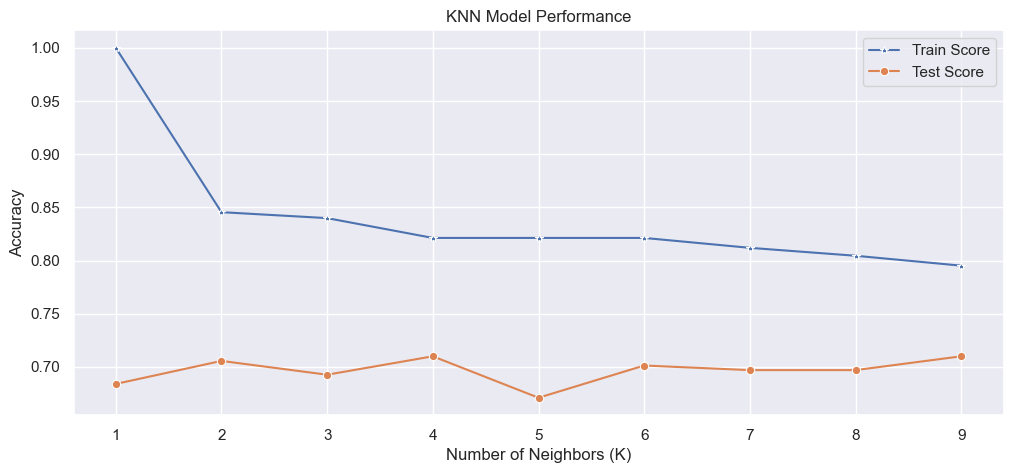

In [89]:
plt.figure(figsize=(12,5))
#p = sns.lineplot(range(1,10),train_scores,marker='*',label='Train Score')
#p = sns.lineplot(range(1,10),test_scores,marker='o',label='Test Score')
p = sns.lineplot(x=range(1,10), y=train_scores, marker='*', label='Train Score')
p = sns.lineplot(x=range(1,10), y=test_scores, marker='o', label='Test Score')

plt.title('KNN Model Performance')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.show()

**<font color='teal'> Fit and score the best number of neighbors based on the plot. </font>**

In [113]:
# 1. Identify the index of the highest test score
# We add 1 because the range started at 1, but list indices start at 0
best_k = test_scores.index(max(test_scores)) + 1
print(f"The best number of neighbors identified from the plot is K = {best_k}")

# 2. Initialize the model with the best K
knn_best = KNeighborsClassifier(n_neighbors=best_k)

# 3. Fit the model to the scaled training data
knn_best.fit(X_train_scaled, y_train)

# 4. Calculate the final scores
train_final_score = knn_best.score(X_train_scaled, y_train)
test_final_score = knn_best.score(X_test_scaled, y_test)

print(f"Final Training Score (K={best_k}): {train_final_score:.4f}")
print(f"Final Testing Score (K={best_k}): {test_final_score:.4f}")

The best number of neighbors identified from the plot is K = 4
Final Training Score (K=4): 0.8417
Final Testing Score (K=4): 0.6926


In [119]:
from sklearn.metrics import confusion_matrix
# 1. Initialize the model with your chosen K
knn = KNeighborsClassifier(n_neighbors = 4) 

# 2. FIT the model to your training data
# This is the step that was missing!
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

pl = confusion_matrix(y_test,y_pred)

**<font color='teal'> Plot the confusion matrix for the model fit above. </font>**

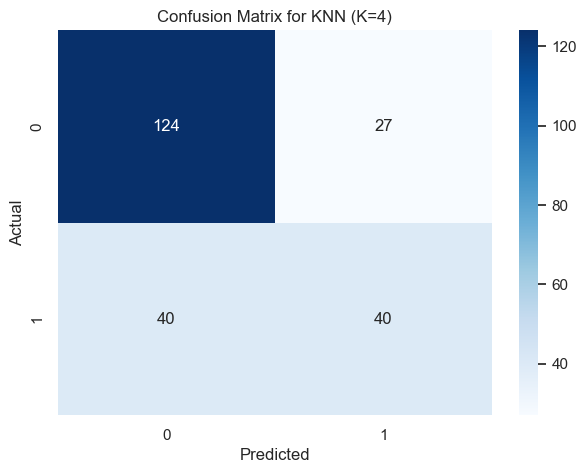

In [122]:
plt.figure(figsize=(7,5))
sns.heatmap(pl, annot=True, fmt='g', cmap='Blues')
plt.title(f'Confusion Matrix for KNN (K={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**<font color='teal'> Print the classification report </font>**

In [125]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       151
           1       0.60      0.50      0.54        80

    accuracy                           0.71       231
   macro avg       0.68      0.66      0.67       231
weighted avg       0.70      0.71      0.70       231



#### In the case of the K nearest neighbors algorithm, the K parameter is one of the most important parameters affecting the model performance.  The model performance isn't horrible, but what if we didn't consider a wide enough range of values in our neighbors for the KNN? An alternative to fitting a loop of models is to use a grid search to identify the proper number. It is common practice to use a grid search method for all adjustable parameters in any type of machine learning algorithm. First, you define the grid — aka the range of values — to test in the parameter being optimized, and then compare the model outcome performance based on the different values in the grid.

#### Run the code in the next cell to see how to implement the grid search method for identifying the best parameter value for the n_neighbors parameter. Notice the param_grid is the range value to test and we apply cross validation with five folds to score each possible value of n_neighbors.

In [128]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors':np.arange(1,50)}
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X,y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

#### Print the best score and best parameter for n_neighbors.

In [130]:
print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score:0.7526440879382056
Best Parameters: {'n_neighbors': 31}


Here you can see that the ideal number of n_neighbors for this model is 14 based on the grid search performed. 

**<font color='teal'> Now, following the KNN example, apply this grid search method to find the optimal number of estimators in a Randon Forest model.
</font>**

In [133]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the range for n_estimators 
# Testing every 50 trees from 50 to 500 is a standard starting point
param_grid = {'n_estimators': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]}

# 2. Initialize the Random Forest Classifier
# random_state ensures your results are reproducible
rf = RandomForestClassifier(random_state=42)

# 3. Initialize GridSearchCV with 5-fold cross-validation
# This will train 50 models (10 parameter options * 5 folds)
rf_cv = GridSearchCV(rf, param_grid, cv=5)

# 4. Fit the grid search to the data
# You can use the scaled or unscaled data; Random Forest is scale-invariant
rf_cv.fit(X_train, y_train)

# 5. Print the optimal results
print("Best Score: " + str(rf_cv.best_score_))
print("Best Parameters: " + str(rf_cv.best_params_))

Best Score: 0.7671512634129456
Best Parameters: {'n_estimators': 450}
